In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('data/used_cars.csv')

In [12]:
print(df.head())

      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2     Lexus                    RX 350 RX 350        2022  22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015  88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021   9,835 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission                 ext_col int_col  \
0        6-Speed A/T                   Black   Black   
1  8-Speed Automatic        

#### Exploratory Data Analysis 

In [13]:
# Number of types of catagories for each variables:
print(df.nunique())

brand             57
model           1898
model_year        34
milage          2818
fuel_type          7
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
clean_title        1
price           1569
dtype: int64


In [14]:
# data cleaning
# we got rid of engine types, transmission, external color, internal color, clean title, model
print(len(df))
df = df[['model_year', 'milage', 'fuel_type',"accident", "price", "brand"]].dropna()
df_new = df[~df['fuel_type'].isin(["not supported", "–"])].copy(deep=True)
# df_new['price'] = df_new['price'].str.replace(r'[$,]', '', regex=True).astype(float)
df_new['price'] = np.log(df_new['price'].str.replace(r'[$,]', '', regex=True).astype(float))
df_new['mileage'] = (
    df_new['milage']
    .str.replace(r'[^\d]', '', regex=True)  # keep only digits
    .astype(float)
)

df_new['fuel_type'] = df_new['fuel_type'].astype('category')
df_new['accident'] = df_new['accident'].map({
    'None reported': 0,
    'At least 1 accident or damage reported': 1
})
data_year = 2023
df_new['age'] = data_year - df_new['model_year'].astype(int)
print(df_new.head())
print(len(df_new))

4009
   model_year      milage      fuel_type  accident      price     brand  \
0        2013  51,000 mi.  E85 Flex Fuel         1   9.239899      Ford   
1        2021  34,742 mi.       Gasoline         1  10.545473   Hyundai   
2        2022  22,372 mi.       Gasoline         0  10.907753     Lexus   
3        2015  88,900 mi.         Hybrid         0   9.648595  INFINITI   
4        2021   9,835 mi.       Gasoline         0  10.463075      Audi   

   mileage  age  
0  51000.0   10  
1  34742.0    2  
2  22372.0    1  
3  88900.0    8  
4   9835.0    2  
3684


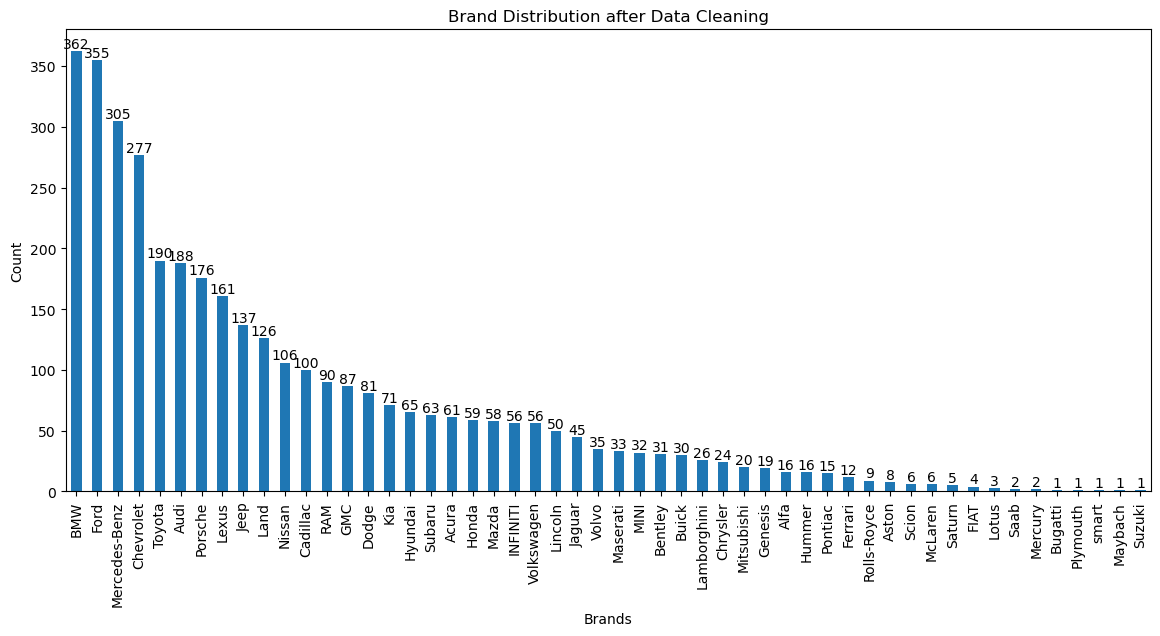

In [15]:
plt.figure(figsize=(14,6))
counts = df_new["brand"].value_counts()

ax = counts.plot(kind='bar')
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Brand Distribution after Data Cleaning')
plt.xlabel('Brands')
plt.ylabel('Count')
plt.show()

As we can see the number of cars in different groups are quite imbalanced. To make it slightly better we merge cars with Hybrid power, plug-in hybrid power and Flex fuel power as one catagory, and make Diesel the same category with gasoline.

In [16]:
df_export = df_new.copy()
df_export = df_export[["mileage", "accident", "fuel_type", "age", "brand", "price"]]
df_export.to_csv("data/cleaned.csv", index=False)

# Set minimum count required to keep a brand separate
threshold = 10

# Count occurrences of each brand
brand_counts = df_export["brand"].value_counts()

# Brands meeting threshold
common_brands = brand_counts[brand_counts >= threshold].index
# print brands that has little observations:
non_common_brands = brand_counts[brand_counts < threshold]
print(non_common_brands)

# Replace rare brands with "Other"
df_export["brand"] = df_export["brand"].where(
    df_export["brand"].isin(common_brands),
    "Other"
)
df_export.to_csv("data/grouped.csv", index=False)

brand
Rolls-Royce    9
Aston          8
Scion          6
McLaren        6
Saturn         5
FIAT           4
Lotus          3
Saab           2
Mercury        2
Bugatti        1
Plymouth       1
smart          1
Maybach        1
Suzuki         1
Name: count, dtype: int64


['Ford' 'Hyundai' 'Lexus' 'INFINITI' 'Audi' 'Acura' 'BMW' 'Land' 'Other'
 'Toyota' 'Lincoln' 'Jaguar' 'Mercedes-Benz' 'Dodge' 'Nissan' 'Chevrolet'
 'Kia' 'Jeep' 'Bentley' 'Honda' 'MINI' 'Porsche' 'Hummer' 'Chrysler'
 'Volvo' 'Cadillac' 'Lamborghini' 'Maserati' 'Genesis' 'Volkswagen' 'GMC'
 'RAM' 'Subaru' 'Alfa' 'Ferrari' 'Mitsubishi' 'Mazda' 'Buick' 'Pontiac']
39


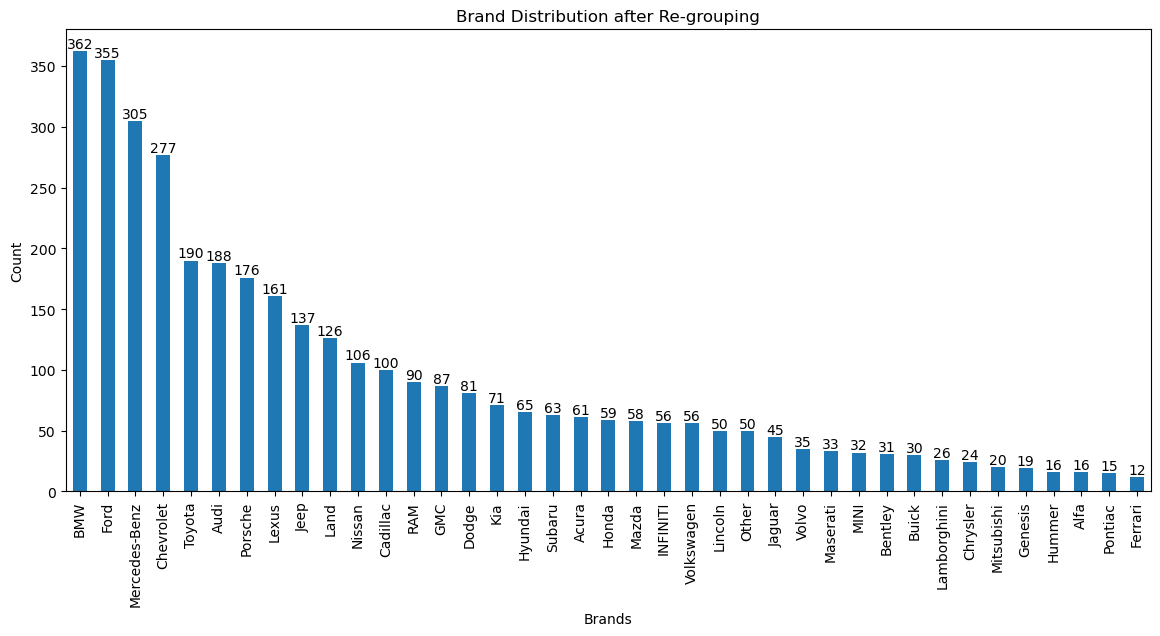

In [17]:
plt.figure(figsize=(14,6))
print(df_export['brand'].unique())
counts = df_export["brand"].value_counts()
print(len(counts))

ax = counts.plot(kind='bar')
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Brand Distribution after Re-grouping')
plt.xlabel('Brands')
plt.ylabel('Count')
plt.show()

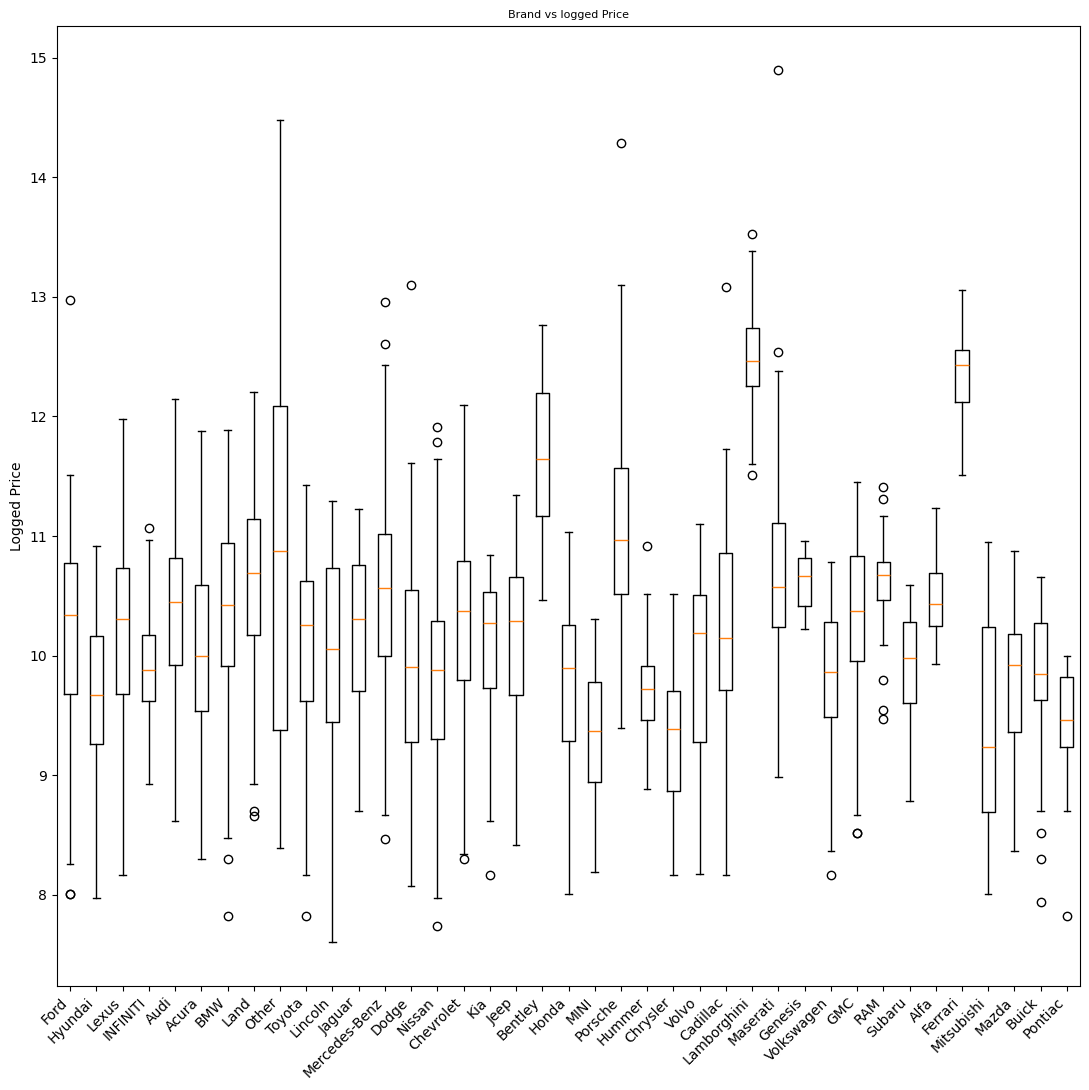

In [18]:
fig, ax = plt.subplots(figsize=(11, 11))

# Boxplot of brand vs price
brand_types = df_export["brand"].unique()
price_groups = [df_export[df_export["brand"] == b]["price"] for b in brand_types]

ax.boxplot(price_groups, tick_labels=brand_types)
ax.set_title('Brand vs logged Price', fontsize=8)
ax.set_ylabel('Logged Price')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
print(df_export.groupby("brand")["price"].var().var())
# print(df_export.groupby("brand")["price"].mean())
# brand_vars = df_export.groupby("brand")["price"].var()
# print(brand_vars.sort_values())
brand_vars = df_export.groupby("brand")["price"].var()

print("Mean variance:", brand_vars.mean())
print("SD of variances:", brand_vars.std())
print("CV:", brand_vars.std()/brand_vars.mean())

0.10502980219086536
Mean variance: 0.4948874824368423
SD of variances: 0.32408301743668294
CV: 0.6548620220517348


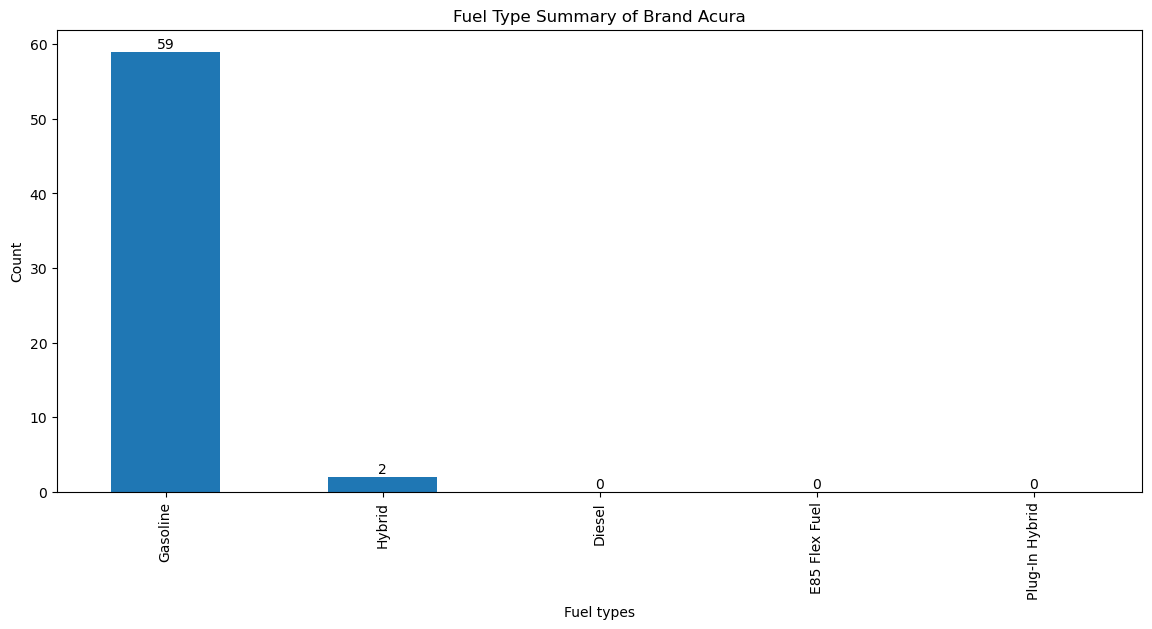

In [19]:
test = df_export[df_export["brand"]=="Acura"]
plt.figure(figsize=(14,6))
counts = test["fuel_type"].value_counts()

ax = counts.plot(kind='bar')
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Fuel Type Summary of Brand Acura')
plt.xlabel('Fuel types')
plt.ylabel('Count')
plt.show()